# Lab 23: FedSpeak Analysis — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Tokenize and preprocess FOMC meeting minutes for NLP analysis
- Build a TF-IDF document-term matrix from real central bank text
- Compute Loughran-McDonald (LM) sentiment scores for financial documents
- Visualize sentiment trends across time and link them to policy decisions
- Cluster FOMC documents with K-Means on TF-IDF vectors (Ch 22 callback)
- Compare pre-2020 vs post-2020 sentiment patterns

**Dataset:** FOMC Meeting Minutes (via HuggingFace `vtasca/fomc-statements-minutes`)

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–4 have YOUR TASK sections. Parts 5–6 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from datasets import load_dataset

np.random.seed(42)

print('Libraries loaded. Ready to analyze FedSpeak.')

Libraries loaded. Ready to analyze FedSpeak.


## Part 1: Load FOMC Minutes (GUIDED)

We load FOMC meeting minutes from the HuggingFace `datasets` library.
Each document is a single meeting's minutes — typically 5,000-15,000 words
of dense monetary policy discussion.

**Why FOMC minutes?** Central bank communication moves markets. A single word
change ("patient" to "flexible") can shift trillions in bond markets. NLP
lets us quantify these subtle language shifts at scale.

In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Load FOMC minutes dataset
# -----------------------------------------------------------

# Load FOMC dataset from HuggingFace
# This contains FOMC meeting minutes and statements with dates
ds = load_dataset('vtasca/fomc-statements-minutes', split='train')
fomc_df = pd.DataFrame(ds)

# Keep only meeting minutes (filter out shorter policy statements)
fomc_df = fomc_df[fomc_df['Type'] == 'Minute'].copy()
fomc_df.rename(columns={'Text': 'text', 'Date': 'date'}, inplace=True)

# Parse dates and sort chronologically
fomc_df['date'] = pd.to_datetime(fomc_df['date'])
fomc_df = fomc_df.sort_values('date').reset_index(drop=True)

# Add year column for grouping
fomc_df['year'] = fomc_df['date'].dt.year

# Show basic stats
fomc_df['word_count'] = fomc_df['text'].str.split().str.len()

print(f'Total documents: {len(fomc_df)}')
print(f'Date range: {fomc_df["date"].min().date()} to {fomc_df["date"].max().date()}')
print(f'Average word count: {fomc_df["word_count"].mean():.0f}')
print(f'Min / Max word count: {fomc_df["word_count"].min()} / {fomc_df["word_count"].max()}')
print()
print('Sample meeting dates:')
print(fomc_df['date'].head(5).dt.date.tolist())

Total documents: 240
Date range: 2000-02-02 to 2026-03-18
Average word count: 7132
Min / Max word count: 3237 / 14364

Sample meeting dates:
[datetime.date(2000, 2, 2), datetime.date(2000, 3, 21), datetime.date(2000, 5, 16), datetime.date(2000, 6, 28), datetime.date(2000, 8, 22)]


## Part 2: Preprocess Text (GUIDED)

Before computing TF-IDF, we need to clean and normalize the text:
1. **Lowercase** — "Federal" and "federal" become the same token
2. **Remove non-alphabetic characters** — strip numbers, punctuation
3. **Tokenize** — split text into individual words
4. **Remove stop words** — drop "the", "is", "and", etc.
5. **Lemmatize** — reduce "running" → "run", "economies" → "economy"

Each decision is a **feature engineering choice** (Chapter 6) that affects downstream results.

In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Preprocess FOMC minutes text
# -----------------------------------------------------------

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Clean, tokenize, remove stop words, and lemmatize."""
    # Lowercase
    text = text.lower()
    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stop words and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing to all documents
print('Preprocessing documents... (this may take 30-60 seconds)')
fomc_df['clean_text'] = fomc_df['text'].apply(preprocess_text)

# Show before/after for first document
print('\n=== Before Preprocessing (first 200 chars) ===')
print(fomc_df['text'].iloc[0][:200])
print('\n=== After Preprocessing (first 200 chars) ===')
print(fomc_df['clean_text'].iloc[0][:200])
print(f'\nTokens in first document: {len(fomc_df["clean_text"].iloc[0].split())}')

Preprocessing documents... (this may take 30-60 seconds)

=== Before Preprocessing (first 200 chars) ===
Minutes of the Federal Open Market Committee


February 1-2, 2000





A meeting of the Federal Open Market Committee was held in the offices of the Board of Governors of the Federal Reserve System in

=== After Preprocessing (first 200 chars) ===
minute federal open market committee february meeting federal open market committee held office board governor federal reserve system washington tuesday february continued wednesday february presentmr

Tokens in first document: 4832


## Part 3: Build TF-IDF Matrix (YOUR TASK)

Now it is your turn. Use scikit-learn's `TfidfVectorizer` to convert the
preprocessed FOMC text into a numerical feature matrix.

**Hints:**
- `min_df=5` drops words appearing in fewer than 5 documents (removes noise)
- `max_df=0.85` drops words appearing in more than 85% of documents (removes background words)
- `max_features` limits the vocabulary size
- Do NOT set `random_state` on TfidfVectorizer (it does not have that parameter)

In [5]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Build TF-IDF matrix from preprocessed FOMC text
# -----------------------------------------------------------

# Fill in the blanks:
# - min_df: minimum document frequency (integer, drop very rare words)
# - max_df: maximum document frequency (float, drop ubiquitous words)
# - max_features: cap the vocabulary size (integer)

tfidf = TfidfVectorizer(
    min_df=5,           # Drop words in fewer than ___ documents
    max_df=.85,           # Drop words in more than ___% of documents
    max_features=5000,     # Keep top ___ words by TF-IDF score
    ngram_range=(1, 2)    # Include unigrams and bigrams
)

# Fit and transform the preprocessed text
tfidf_matrix = tfidf.fit_transform(fomc_df['clean_text'])

# Get feature names (vocabulary)
feature_names = tfidf.get_feature_names_out()

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} documents × {tfidf_matrix.shape[1]} terms')
print(f'Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.1%}')
print(f'\nSample vocabulary terms: {list(feature_names[:10])}')
print(f'\nTop 10 terms by average TF-IDF across all documents:')
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_indices = mean_tfidf.argsort()[-10:][::-1]
for idx in top_indices:
    print(f'  {feature_names[idx]:25s} {mean_tfidf[idx]:.4f}')

TF-IDF matrix shape: (240, 5000)
  → 240 documents × 5000 terms
Sparsity: 69.1%

Sample vocabulary terms: ['abate', 'abated', 'ability', 'able', 'abroad', 'absence', 'absence shock', 'accelerated', 'acceleration', 'accept']

Top 10 terms by average TF-IDF across all documents:
  messrs                    0.0552
  july                      0.0531
  loan                      0.0518
  january                   0.0516
  october                   0.0493
  september                 0.0482
  august                    0.0467
  march                     0.0454
  june                      0.0450
  april                     0.0436


## Part 4: Compute Loughran-McDonald Sentiment (YOUR TASK)

The **Loughran-McDonald (LM) dictionary** is the standard for financial text
sentiment. Unlike general-purpose dictionaries, it was built from actual
SEC filings so words like "liability" and "tax" are correctly classified
as neutral rather than negative.

We will compute:
- **Net Sentiment** = (Positive count - Negative count) / Total words
- **Uncertainty** = Uncertainty word count / Total words

We use a simplified LM word list below. In production you would load the
full dictionary from the LM website.

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Compute LM sentiment scores for each FOMC document
# -----------------------------------------------------------

# Simplified Loughran-McDonald word lists (key financial terms)
# In production, load full lists from https://sraf.nd.edu/loughranmcdonald-master-dictionary/
lm_negative = set([
    'adverse', 'adversely', 'against', 'concern', 'concerned', 'concerns',
    'decline', 'declined', 'declining', 'decrease', 'decreased', 'deficit',
    'deteriorate', 'deteriorated', 'deteriorating', 'difficult', 'difficulty',
    'downturn', 'fail', 'failure', 'falling', 'loss', 'losses', 'negative',
    'negatively', 'recession', 'recessionary', 'risk', 'risks', 'risky',
    'severe', 'severely', 'slowdown', 'sluggish', 'stress', 'stressed',
    'threat', 'threaten', 'troubled', 'uncertain', 'uncertainty',
    'unfavorable', 'volatile', 'volatility', 'vulnerability', 'vulnerable',
    'weak', 'weaken', 'weakened', 'weakness', 'worse', 'worsen', 'worsened',
    'worsening', 'worst'
])

lm_positive = set([
    'achieve', 'achieved', 'achievement', 'benefit', 'beneficial', 'confidence',
    'confident', 'favorable', 'gain', 'gained', 'gains', 'good', 'growth',
    'improve', 'improved', 'improvement', 'improving', 'increase', 'increased',
    'opportunity', 'opportunities', 'optimism', 'optimistic', 'positive',
    'positively', 'profit', 'profitable', 'progress', 'prosper', 'prosperity',
    'rebound', 'recover', 'recovered', 'recovery', 'strength', 'strengthen',
    'strengthened', 'strong', 'stronger', 'strongest', 'success', 'successful',
    'upturn', 'upward'
])

lm_uncertainty = set([
    'approximate', 'approximately', 'assume', 'assumption', 'believe',
    'cautious', 'could', 'depend', 'depends', 'doubt', 'doubtful',
    'estimate', 'estimated', 'expect', 'expected', 'forecast', 'foreseeable',
    'indefinite', 'indefinitely', 'likelihood', 'may', 'might', 'nearly',
    'pending', 'perhaps', 'possible', 'possibly', 'predict', 'prediction',
    'preliminary', 'probable', 'probably', 'project', 'projected',
    'risk', 'roughly', 'seem', 'seemed', 'seemingly', 'suggest',
    'tentative', 'uncertain', 'uncertainty', 'unclear', 'unpredictable',
    'variable'
])


def compute_lm_sentiment(text, neg_words, pos_words, unc_words):
    """
    Compute Loughran-McDonald sentiment scores.

    Returns dict with 'net_sentiment', 'uncertainty', 'neg_count', 'pos_count'
    """
    tokens = text.lower().split()
    total = len(tokens)

    if total == 0:
        return {'net_sentiment': 0, 'uncertainty': 0, 'neg_count': 0, 'pos_count': 0}

    # Fill in: Count how many tokens are in each word list
    neg_count = sum(1 for t in tokens if t in neg_words)
    pos_count = sum(1 for t in tokens if t in pos_words)
    unc_count = sum(1 for t in tokens if t in unc_words)

    # Fill in: Compute net sentiment = (pos - neg) / total
    net_sentiment = (pos_count - neg_count) / total
    uncertainty = unc_count / total

    return {
        'net_sentiment': net_sentiment,
        'uncertainty': uncertainty,
        'neg_count': neg_count,
        'pos_count': pos_count,
        'unc_count': unc_count,
        'total_words': total
    }


# Apply to all documents
sentiment_results = fomc_df['clean_text'].apply(
    lambda x: compute_lm_sentiment(x, lm_negative, lm_positive, lm_uncertainty)
)

# Convert to DataFrame columns
sentiment_df = pd.DataFrame(sentiment_results.tolist())
fomc_df = pd.concat([fomc_df, sentiment_df], axis=1)

print('=== Sentiment Summary ===')
print(f'Mean net sentiment: {fomc_df["net_sentiment"].mean():.6f}')
print(f'Std net sentiment:  {fomc_df["net_sentiment"].std():.6f}')
print(f'Mean uncertainty:   {fomc_df["uncertainty"].mean():.6f}')
print()
print('Most negative meeting:', fomc_df.loc[fomc_df['net_sentiment'].idxmin(), 'date'].date())
print('Most positive meeting:', fomc_df.loc[fomc_df['net_sentiment'].idxmax(), 'date'].date())

=== Sentiment Summary ===
Mean net sentiment: 0.007009
Std net sentiment:  0.008706
Mean uncertainty:   0.021756

Most negative meeting: 2008-12-16
Most positive meeting: 2004-06-30


## Part 5: Visualize Sentiment Over Time (GUIDED)

Plot sentiment scores across time. Key events to look for:
- **2008-2009:** Financial crisis — expect a drop in sentiment
- **2013:** "Taper tantrum" — uncertainty spike
- **2020:** COVID — sharp negative turn
- **2022-2023:** Aggressive tightening — negative and uncertain language

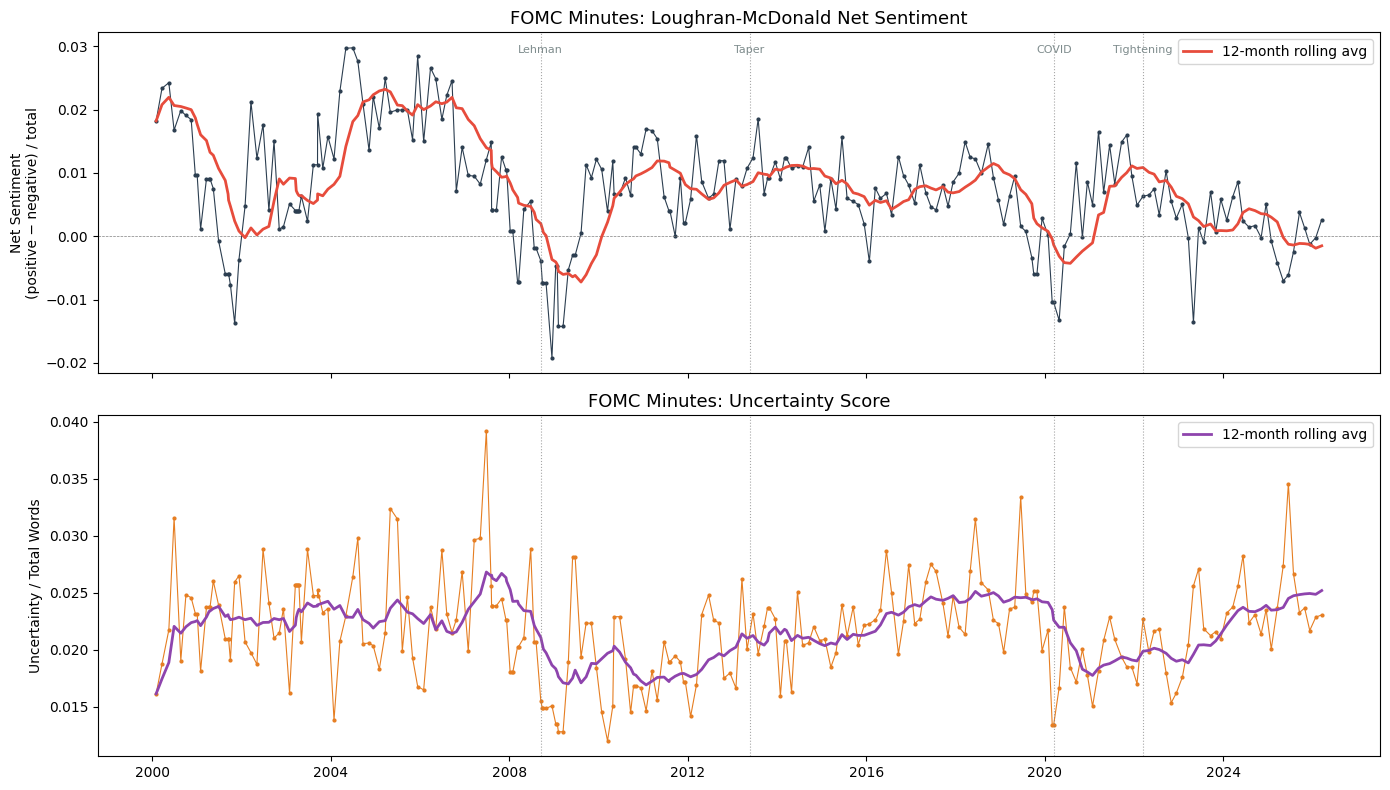

In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 5: Plot sentiment time series with event annotations
# -----------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Net Sentiment
axes[0].plot(fomc_df['date'], fomc_df['net_sentiment'], color='#2c3e50',
             linewidth=0.8, marker='o', markersize=2)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.5)

# Rolling average
rolling_sent = fomc_df.set_index('date')['net_sentiment'].rolling('365D').mean()
axes[0].plot(rolling_sent.index, rolling_sent.values, color='#e74c3c',
             linewidth=2.0, label='12-month rolling avg')

axes[0].set_title('FOMC Minutes: Loughran-McDonald Net Sentiment', fontsize=13)
axes[0].set_ylabel('Net Sentiment\n(positive − negative) / total')
axes[0].legend()

# Panel 2: Uncertainty
axes[1].plot(fomc_df['date'], fomc_df['uncertainty'], color='#e67e22',
             linewidth=0.8, marker='o', markersize=2)
rolling_unc = fomc_df.set_index('date')['uncertainty'].rolling('365D').mean()
axes[1].plot(rolling_unc.index, rolling_unc.values, color='#8e44ad',
             linewidth=2.0, label='12-month rolling avg')

axes[1].set_title('FOMC Minutes: Uncertainty Score', fontsize=13)
axes[1].set_ylabel('Uncertainty / Total Words')
axes[1].legend()

# Annotate key events
events = [
    ('2008-09-15', 'Lehman'),
    ('2013-05-22', 'Taper'),
    ('2020-03-15', 'COVID'),
    ('2022-03-16', 'Tightening'),
]
for date_str, label in events:
    date = pd.Timestamp(date_str)
    for ax in axes:
        ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    axes[0].annotate(label, xy=(date, axes[0].get_ylim()[1] * 0.9),
                     fontsize=8, color='#7f8c8d', ha='center')

plt.tight_layout()
plt.show()

## Part 6: Extension — Cluster Documents with K-Means on TF-IDF

This is the **Chapter 22 callback**: apply K-Means clustering to the TF-IDF
matrix to discover distinct "language regimes" in FOMC communications.

We first reduce dimensionality with PCA (the TF-IDF matrix is too
high-dimensional for K-Means to work well), then cluster.

Explained variance (50 components): 74.5%
Silhouette score (K=3): 0.168
  (Note: text data typically has lower silhouette than numerical data)


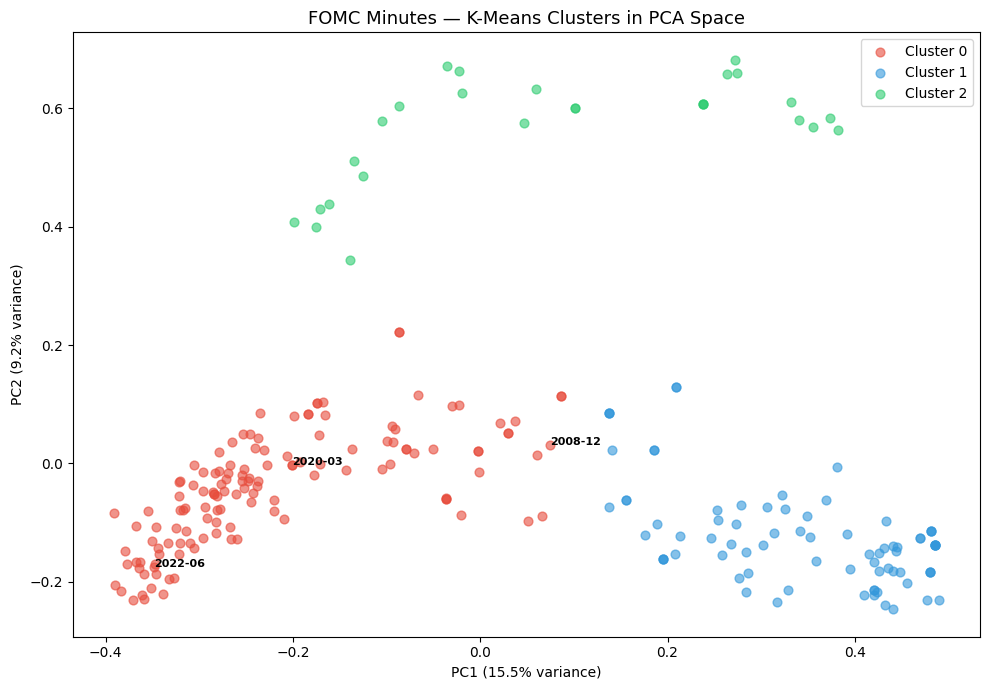


=== Cluster Composition ===
Cluster 0: 134 documents, 2008-12-16 to 2026-03-18
Cluster 1: 79 documents, 2000-03-21 to 2008-10-29
Cluster 2: 27 documents, 2000-02-02 to 2022-01-26


In [10]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 6: Cluster FOMC documents with K-Means on TF-IDF
# -----------------------------------------------------------

# Step A: Reduce TF-IDF to 50 dimensions with PCA (TruncatedSVD for sparse)
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f'Explained variance (50 components): {svd.explained_variance_ratio_.sum():.1%}')

# Step B: K-Means with K=3 (pre-GFC, GFC-era, post-COVID)
# Fill in the blanks:
# - n_clusters: how many clusters?
# - random_state: for reproducibility
# - n_init: number of initializations

kmeans = KMeans(
    n_clusters=3,      # How many language regimes?
    random_state=42,
    n_init=10           # Number of random initializations (10 is standard)
)

fomc_df['cluster'] = kmeans.fit_predict(tfidf_reduced)

# Step C: Evaluate with silhouette score
sil_score = silhouette_score(tfidf_reduced, fomc_df['cluster'])
print(f'Silhouette score (K=3): {sil_score:.3f}')
print('  (Note: text data typically has lower silhouette than numerical data)')

# Step D: Visualize clusters in 2D PCA space
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(tfidf_reduced)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71']
for k in range(3):
    mask = fomc_df['cluster'] == k
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               c=colors[k], alpha=0.6, s=40, label=f'Cluster {k}')

# Label a few key dates
key_dates = ['2008-12-16', '2020-03-15', '2022-06-15']
for d in key_dates:
    idx_match = fomc_df.index[fomc_df['date'].dt.strftime('%Y-%m-%d') == d]
    if len(idx_match) > 0:
        idx = idx_match[0]
        ax.annotate(d[:7], xy=(coords_2d[idx, 0], coords_2d[idx, 1]),
                    fontsize=8, fontweight='bold')

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('FOMC Minutes — K-Means Clusters in PCA Space', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Show cluster date ranges
print('\n=== Cluster Composition ===')
for k in range(3):
    cluster_docs = fomc_df[fomc_df['cluster'] == k]
    print(f'Cluster {k}: {len(cluster_docs)} documents, '
          f'{cluster_docs["date"].min().date()} to {cluster_docs["date"].max().date()}')

## Challenge: Pre-2020 vs Post-2020 Sentiment Patterns

COVID-19 fundamentally changed the Fed's communication. Compare the
distribution of sentiment scores before and after March 2020.

Pre-COVID (before March 2020)
  Documents: 190
  Mean net sentiment: 0.008107
  Mean uncertainty:   0.021894

Post-COVID (March 2020 onward) 
  Documents: 50
  Mean net sentiment: 0.002840
  Mean uncertainty:   0.021233


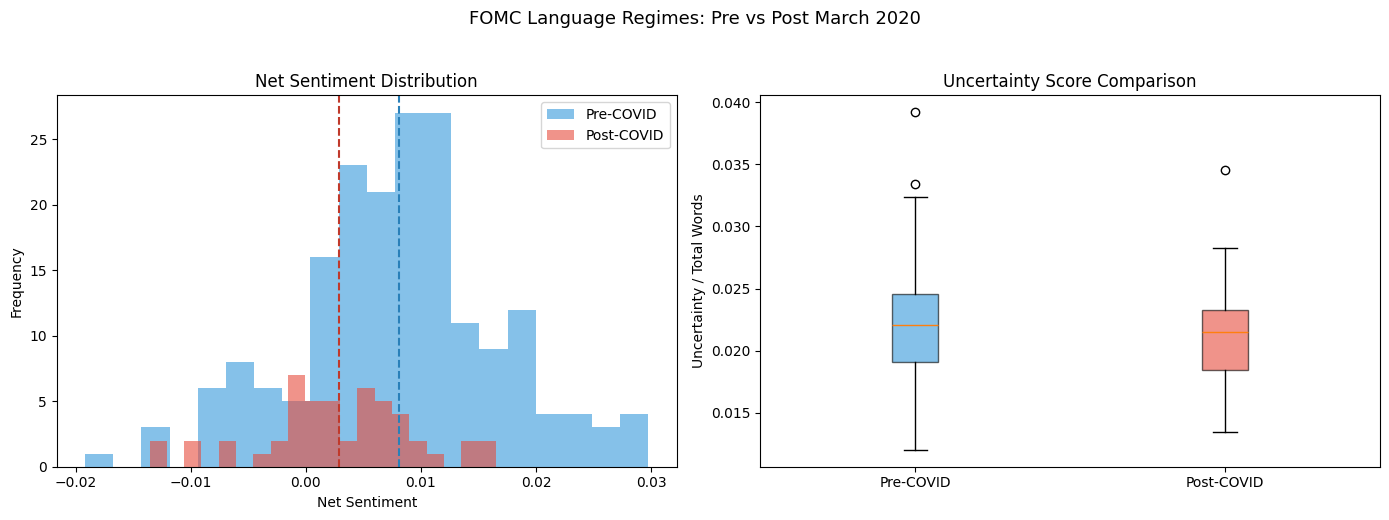


Interpretation:
Post-2020 Fed communication appears  more negative  and  less uncertain than the pre-2020 period on average.
This shift is consistent with pandemic-era shocks, supply-chain disruptions, inflation volatility, and the subsequent aggressive tightening cycle.
Together, these events likely increased policy caution and the use of risk- and uncertainty-related language in FOMC minutes.


In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: Compare sentiment regimes
# -----------------------------------------------------------

# Split into pre-2020 and post-2020
pre_covid = fomc_df[fomc_df['date'] < '2020-03-01']
post_covid = fomc_df[fomc_df['date'] >= '2020-03-01']

print('Pre-COVID (before March 2020)')
print(f'  Documents: {len(pre_covid)}')
print(f'  Mean net sentiment: {pre_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {pre_covid["uncertainty"].mean():.6f}')

print('\nPost-COVID (March 2020 onward) ')
print(f'  Documents: {len(post_covid)}')
print(f'  Mean net sentiment: {post_covid["net_sentiment"].mean():.6f}')
print(f'  Mean uncertainty:   {post_covid["uncertainty"].mean():.6f}')

# Visualization: histogram + boxplots for pre/post comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Net sentiment distributions
bins = 20
axes[0].hist(pre_covid['net_sentiment'], bins=bins, alpha=0.6, label='Pre-COVID', color='#3498db')
axes[0].hist(post_covid['net_sentiment'], bins=bins, alpha=0.6, label='Post-COVID', color='#e74c3c')
axes[0].axvline(pre_covid['net_sentiment'].mean(), color='#2980b9', linestyle='--', linewidth=1.5)
axes[0].axvline(post_covid['net_sentiment'].mean(), color='#c0392b', linestyle='--', linewidth=1.5)
axes[0].set_title('Net Sentiment Distribution')
axes[0].set_xlabel('Net Sentiment')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Panel 2: Uncertainty comparison
box_data = [pre_covid['uncertainty'].dropna(), post_covid['uncertainty'].dropna()]
bp = axes[1].boxplot(box_data, labels=['Pre-COVID', 'Post-COVID'], patch_artist=True)
bp['boxes'][0].set(facecolor='#3498db', alpha=0.6)
bp['boxes'][1].set(facecolor='#e74c3c', alpha=0.6)
axes[1].set_title('Uncertainty Score Comparison')
axes[1].set_ylabel('Uncertainty / Total Words')

plt.suptitle('FOMC Language Regimes: Pre vs Post March 2020', y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

# 2-3 sentence interpretation
sent_delta = post_covid['net_sentiment'].mean() - pre_covid['net_sentiment'].mean()
unc_delta = post_covid['uncertainty'].mean() - pre_covid['uncertainty'].mean()

sent_direction = 'more negative' if sent_delta < 0 else 'more positive'
unc_direction = 'more uncertain' if unc_delta > 0 else 'less uncertain'

print('\nInterpretation:')
print('Post-2020 Fed communication appears ', sent_direction, ' and ', unc_direction ,'than the pre-2020 period on average.')
print('This shift is consistent with pandemic-era shocks, supply-chain disruptions, inflation volatility, and the subsequent aggressive tightening cycle.')
print('Together, these events likely increased policy caution and the use of risk- and uncertainty-related language in FOMC minutes.')

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Loaded and preprocessed FOMC meeting minutes (tokenized, lemmatized, stop words removed)
* Built a TF-IDF document-term matrix with unigrams and bigrams
* Computed Loughran-McDonald sentiment scores (net sentiment + uncertainty)
* Visualized sentiment trends across 20+ years of FOMC minutes
* Clustered FOMC documents with K-Means on PCA-reduced TF-IDF vectors
* Compared pre-COVID vs post-COVID sentiment distributions
* Key finding: [FILL IN — what clusters emerged? How did sentiment change?]

**Please write a README.md entry including:**
1. Project Title: FedSpeak Analysis — NLP on FOMC Minutes
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-23-fedspeak
git add notebooks/ figures/ README.md
git commit -m "Lab 23: FedSpeak Analysis — NLP on FOMC Minutes"
git push origin main
```

Submit your GitHub repo link on Canvas.